# PLOG

In [1]:
# --------------------------------------------------------
# External packages
import matplotlib.pyplot as plt
import numpy as np
import jax.numpy as jnp

# --------------------------------------------------------
# KiRATE modules
from KiRATE.kinetics import Plog

Introduced by J. Miller, as a generalized polynomial fitting for temperature and pressure dependent kinetic constants, by defining the following expression for the kinetic constant:

- Equation
  > $k_f \left(T, P_{i}\right) = \sum_{k=1}^{M} A_{i, k} \: T^{n_{i, k}} \: exp\left(-E_{act}^{i,k}/(RT)\right), \quad i=1, ..., Np, \quad M \geq 1$
  
  at a set of pressures, $P = P_{1}, P_{2}, ..., P_{Np}$. $M$ and $Np$ are user specified numbers. The extrapolation is bounded by the two pressure limits, $P_{1}$ and $P_{Np}$. To calculate $k \left(T, P_{i}\right)$ for any pressure, interpolate $logk$ as a linear function of $logP$. If $P$ is between $P_{i}$ and $P_{i+1}$ for any temperature a rate constant can be find from:
  > $logk_f \left(T, P\right) = logk_f\left(T, P_{i}\right) + \left(logP - logP_{i}\right) \frac{logk_f\left(T, P_{i+1}\right) - logk_f\left(T, P_{i}\right)}{logP_{i+1} - logP_{i}}$
- CHEMKIN representation
  >```
  > OH+NO=HONO		0.00000E+00 0.00000E+00 0.00000E+00
  >  PLOG / 1.00000E-02	5.02000E+21 -4.24000E+00 8.98900E+02 /
  >  PLOG / 1.00000E-01	5.31000E+22 -4.24000E+00 1.18400E+03 /
  >  PLOG / 3.16000E-01	1.38000E+23 -4.22000E+00 1.37600E+03 /
  >  PLOG / 1.00000E+00	3.09000E+23 -4.17000E+00 1.62100E+03 /
  >  PLOG / 3.16000E+00	5.45000E+23 -4.09000E+00 1.91100E+03 /
  >  PLOG / 1.00000E+01	6.35000E+23 -3.97000E+00 2.22200E+03 /
  >  PLOG / 3.16000E+01	3.68000E+23 -3.75000E+00 2.50100E+03 /
  >  PLOG / 1.00000E+02	7.29000E+22 -3.41000E+00 2.66000E+03 /
  >```
- Internal representation

  **From dictionary**
    >```python
    > plog_reaction = Plog(
    >     parameters={
    >         0.01:  {"A": 5.02e+21, "n": -4.24, "Ea":  898.9},
    >         0.1:   {"A": 5.31e+22, "n": -4.24, "Ea": 1184.0},
    >         0.316: {"A": 1.38e+23, "n": -4.22, "Ea": 1376.0},
    >         1.0:   {"A": 3.09e+23, "n": -4.17, "Ea": 1621.0},
    >         3.16:  {"A": 5.45e+23, "n": -4.09, "Ea": 1911.0},
    >         10.0:  {"A": 6.35e+23, "n": -3.97, "Ea": 2222.0},
    >         31.6:  {"A": 3.68e+23, "n": -3.75, "Ea": 2501.0},
    >         100.0: {"A": 7.29e+22, "n": -3.41, "Ea": 2660.0},
    >     },
    >     name="OH+NO=HONO"
    > )
    >```

  **From CHEMKIN string**
    >```python
    > reaction = Plog.from_chemkin(
    >     """
    >     OH+NO=HONO		0.00000E+00 0.00000E+00 0.00000E+00
    >     PLOG / 1.00000E-02	5.02000E+21 -4.24000E+00 8.98900E+02 /
    >     PLOG / 1.00000E-01	5.31000E+22 -4.24000E+00 1.18400E+03 /
    >     PLOG / 3.16000E-01	1.38000E+23 -4.22000E+00 1.37600E+03 /
    >     PLOG / 1.00000E+00	3.09000E+23 -4.17000E+00 1.62100E+03 /
    >     PLOG / 3.16000E+00	5.45000E+23 -4.09000E+00 1.91100E+03 /
    >     PLOG / 1.00000E+01	6.35000E+23 -3.97000E+00 2.22200E+03 /
    >     PLOG / 3.16000E+01	3.68000E+23 -3.75000E+00 2.50100E+03 /
    >     PLOG / 1.00000E+02	7.29000E+22 -3.41000E+00 2.66000E+03 /
    >     """
    > )
    >```

In [2]:
# --------------------------------------------------------
# Dictionary initialization
reaction = Plog(
    parameters={
        0.01:  {"A": 5.02e+21, "n": -4.24, "Ea":  898.9},
        0.1:   {"A": 5.31e+22, "n": -4.24, "Ea": 1184.0},
        0.316: {"A": 1.38e+23, "n": -4.22, "Ea": 1376.0},
        1.0:   {"A": 3.09e+23, "n": -4.17, "Ea": 1621.0},
        3.16:  {"A": 5.45e+23, "n": -4.09, "Ea": 1911.0},
        10.0:  {"A": 6.35e+23, "n": -3.97, "Ea": 2222.0},
        31.6:  {"A": 3.68e+23, "n": -3.75, "Ea": 2501.0},
        100.0: {"A": 7.29e+22, "n": -3.41, "Ea": 2660.0},
    },
    name="OH+NO=HONO"
)

# --------------------------------------------------------
# Construction from a CHEMKIN-fromatted string
reaction = Plog.from_chemkin(
    """
    OH+NO=HONO		0.00000E+00 0.00000E+00 0.00000E+00
     PLOG / 1.00000E-02	5.02000E+21 -4.24000E+00 8.98900E+02 /
     PLOG / 1.00000E-01	5.31000E+22 -4.24000E+00 1.18400E+03 /
     PLOG / 3.16000E-01	1.38000E+23 -4.22000E+00 1.37600E+03 /
     PLOG / 1.00000E+00	3.09000E+23 -4.17000E+00 1.62100E+03 /
     PLOG / 3.16000E+00	5.45000E+23 -4.09000E+00 1.91100E+03 /
     PLOG / 1.00000E+01	6.35000E+23 -3.97000E+00 2.22200E+03 /
     PLOG / 3.16000E+01	3.68000E+23 -3.75000E+00 2.50100E+03 /
     PLOG / 1.00000E+02	7.29000E+22 -3.41000E+00 2.66000E+03 /
    """
)

# --------------------------------------------------------
# Object inspection
print(f"Representer:\n{repr(reaction)}\n")
print(f"String representation:\n{str(reaction)}") # This always print the CHEMKIN-formatted string

Representer:
Plog(
 name = OH+NO=HONO
 num_p_levels = 8
 pressure_levels = [
  P = 1.00000e-02 atm:
   Arrhenius(
    name = OH+NO=HONO (0.01)
    A    = 5.02000e+21
    n    = -4.24000e+00
    Ea   = 8.98900e+02
   )
  P = 1.00000e-01 atm:
   Arrhenius(
    name = OH+NO=HONO (0.1)
    A    = 5.31000e+22
    n    = -4.24000e+00
    Ea   = 1.18400e+03
   )
  P = 3.16000e-01 atm:
   Arrhenius(
    name = OH+NO=HONO (0.316)
    A    = 1.38000e+23
    n    = -4.22000e+00
    Ea   = 1.37600e+03
   )
  P = 1.00000e+00 atm:
   Arrhenius(
    name = OH+NO=HONO (1.0)
    A    = 3.09000e+23
    n    = -4.17000e+00
    Ea   = 1.62100e+03
   )
  P = 3.16000e+00 atm:
   Arrhenius(
    name = OH+NO=HONO (3.16)
    A    = 5.45000e+23
    n    = -4.09000e+00
    Ea   = 1.91100e+03
   )
  P = 1.00000e+01 atm:
   Arrhenius(
    name = OH+NO=HONO (10.0)
    A    = 6.35000e+23
    n    = -3.97000e+00
    Ea   = 2.22200e+03
   )
  P = 3.16000e+01 atm:
   Arrhenius(
    name = OH+NO=HONO (31.6)
    A    = 3

## Rate constant computation

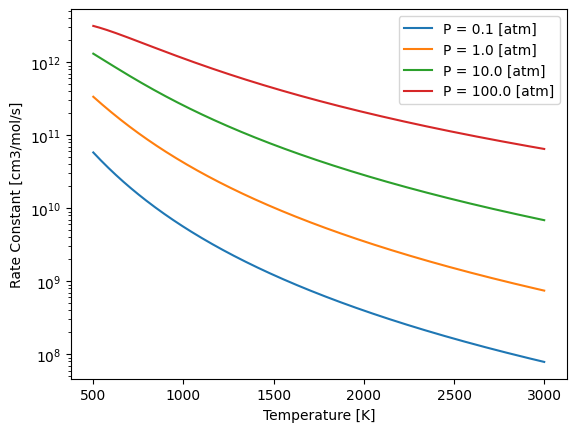

In [3]:
T_range = jnp.linspace(500, 3000, 300)
P_range = jnp.array([0.1, 1, 10, 100])

k_plog = reaction.rate_constant(T_range, P_range)

for i, j in enumerate(k_plog):
    plt.semilogy(T_range, j, label=f"P = {P_range[i]} [atm]")
    
plt.xlabel("Temperature [K]")
plt.ylabel("Rate Constant [cm3/mol/s]")
plt.legend()
plt.legend()
plt.show()